In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("smartcart_customers.csv")

In [11]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data preprocessing 


#1.Handle missing value

In [12]:
df["Income"]=df["Income"].fillna(df["Income"].median())

In [13]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

# Feature Engineering 

In [38]:
df = df.drop("ID", axis=1)

In [39]:
#AGE
df["Age"]=2026-df["Year_Birth"]

In [40]:
df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,total spanding,Total_children
0,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,...,8,10,4,7,0,1,69,663,1789,0
1,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,...,1,1,2,5,0,0,72,113,29,2
2,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,...,8,2,10,4,0,0,61,312,887,0
3,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,...,2,0,4,6,0,0,42,139,63,1
4,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,...,5,3,6,5,0,0,45,161,468,1


In [41]:
# Customer_Tenure_Days
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)
reference_date= df["Dt_Customer"].max()

df["Customer_Tenure_Days"]=(reference_date-df["Dt_Customer"]).dt.days
df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,total spanding,Total_children
0,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,...,8,10,4,7,0,1,69,663,1789,0
1,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,...,1,1,2,5,0,0,72,113,29,2
2,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,...,8,2,10,4,0,0,61,312,887,0
3,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,...,2,0,4,6,0,0,42,139,63,1
4,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,...,5,3,6,5,0,0,45,161,468,1


In [42]:
df.columns

Index(['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'total spanding',
       'Total_children'],
      dtype='str')

In [46]:
df["Total_Spending"] = (
    df["MntWines"]
    + df["MntFruits"]
    + df["MntMeatProducts"]
    + df["MntFishProducts"]
    + df["MntSweetProducts"]
    + df["MntGoldProds"]
)

In [47]:
df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,total spanding,Total_children,Total_Spending
0,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,...,10,4,7,0,1,69,663,1789,0,1617
1,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,...,1,2,5,0,0,72,113,29,2,27
2,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,...,2,10,4,0,0,61,312,887,0,776
3,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,...,0,4,6,0,0,42,139,63,1,53
4,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,...,3,6,5,0,0,45,161,468,1,422


In [48]:
df["Total_children"]=df["Kidhome"]+df["Teenhome"]
df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,total spanding,Total_children,Total_Spending
0,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,...,10,4,7,0,1,69,663,1789,0,1617
1,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,...,1,2,5,0,0,72,113,29,2,27
2,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,...,2,10,4,0,0,61,312,887,0,776
3,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,...,0,4,6,0,0,42,139,63,1,53
4,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,...,3,6,5,0,0,45,161,468,1,422


In [55]:
#Education 
df["Education"].value_counts()

# Undergraduate, Graduate, Postgraduate
df ["Education"]=df ["Education"]. replace({
    "Basic": "Undergraduate", "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate", "PhD": "Postgraduate"
})

In [56]:
df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,total spanding,Total_children,Total_Spending
0,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,88,...,10,4,7,0,1,69,663,1789,0,1617
1,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,1,...,1,2,5,0,0,72,113,29,2,27
2,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,49,...,2,10,4,0,0,61,312,887,0,776
3,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,4,...,0,4,6,0,0,42,139,63,1,53
4,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,43,...,3,6,5,0,0,45,161,468,1,422


#Marital_Status

In [64]:
df["Living_With"] = df ["Marital_Status"]. replace({
"Married": "Partner", "Together": "Partner",
"Single": "Alone", "Divorced": "Alone",
"Widow": "Alone", "Absurd": "Alone", "YOLO": "Alone"})

In [65]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

#drop cloumns 


In [69]:
df.columns

Index(['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'total spanding',
       'Total_children', 'Total_Spending', 'Living_With'],
      dtype='str')

#OUTLIERS 

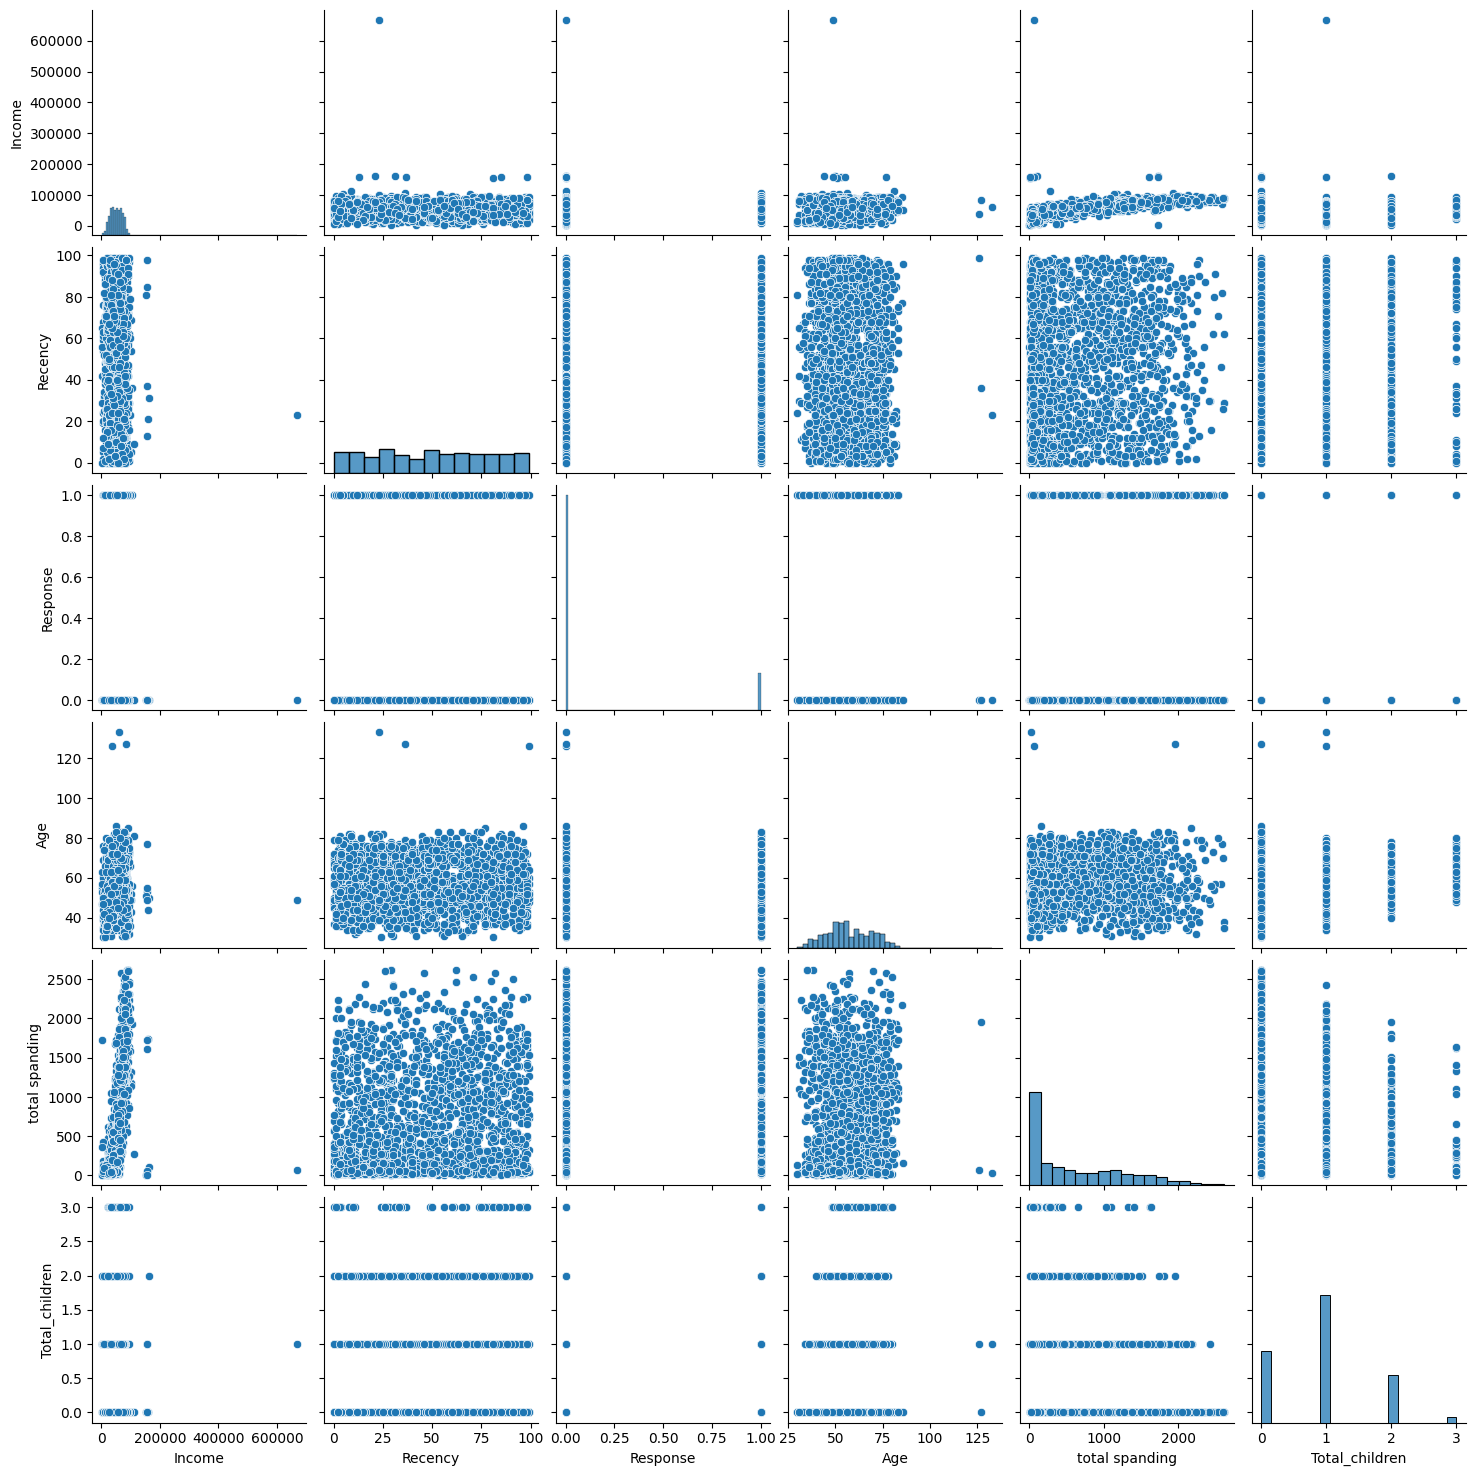

In [77]:
cols=["Income","Recency","Response","Age","total spanding","Total_children"]

sns.pairplot(df[cols])

In [83]:
# Remove outliers

print("data size with outliers:", len(df))

df = df[ (df["Age"] < 90) ]
df = df[ (df["Income"] < 600_000) ]

print("data size without outliers:", len(df))

data size with outliers: 2237
data size without outliers: 2236


# Heat map 


In [84]:
corr=df.corr(numeric_only=True)

In [85]:
corr

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,total spanding,Total_children,Total_Spending
Income,1.000000,-0.510441,0.034315,0.007829,0.686080,0.504911,0.684176,0.518462,0.518126,0.383548,...,0.693781,0.628075,-0.646382,-0.027871,0.161121,0.198835,-0.023677,0.788651,-0.340550,0.789375
Kidhome,-0.510441,1.000000,-0.035339,0.007964,-0.496166,-0.372442,-0.436901,-0.387404,-0.370486,-0.349462,...,-0.502331,-0.500192,0.447626,0.036336,-0.080005,-0.233894,-0.054036,-0.558071,0.690256,-0.556719
Teenhome,0.034315,-0.035339,1.000000,0.016746,0.005047,-0.176117,-0.261171,-0.204177,-0.162527,-0.020447,...,-0.110551,0.050177,0.134636,0.007553,-0.154941,0.363172,0.017871,-0.147779,0.698721,-0.138197
Recency,0.007829,0.007964,0.016746,1.000000,0.016321,-0.003717,0.023446,0.001314,0.022796,0.017168,...,0.025226,0.000771,-0.021850,0.005361,-0.198781,0.019396,0.024238,0.019764,0.017826,0.020842
MntWines,0.686080,-0.496166,0.005047,0.016321,1.000000,0.388472,0.561886,0.398956,0.385845,0.386234,...,0.634716,0.642313,-0.320287,-0.035974,0.247280,0.162809,0.166068,0.874895,-0.351522,0.891696
MntFruits,0.504911,-0.372442,-0.176117,-0.003717,0.388472,1.000000,0.542030,0.594415,0.567030,0.389999,...,0.487274,0.463136,-0.417405,-0.002813,0.125854,0.013657,0.067104,0.628973,-0.394121,0.613122
MntMeatProducts,0.684176,-0.436901,-0.261171,0.023446,0.561886,0.542030,1.000000,0.567813,0.523329,0.348727,...,0.723473,0.479983,-0.539183,-0.020750,0.236548,0.030729,0.092605,0.843083,-0.501844,0.842624
MntFishProducts,0.518462,-0.387404,-0.204177,0.001314,0.398956,0.594415,0.567813,1.000000,0.579490,0.422018,...,0.533969,0.459997,-0.445729,-0.018842,0.111325,0.042359,0.080636,0.691239,-0.425148,0.642335
MntSweetProducts,0.518126,-0.370486,-0.162527,0.022796,0.385845,0.567030,0.523329,0.579490,1.000000,0.369084,...,0.490416,0.448673,-0.423215,-0.020432,0.117263,0.019379,0.081012,0.617783,-0.382882,0.602610
MntGoldProds,0.383548,-0.349462,-0.020447,0.017168,0.386234,0.389999,0.348727,0.422018,0.369084,1.000000,...,0.436909,0.383124,-0.249041,-0.029902,0.140595,0.057419,0.160189,0.528915,-0.264964,0.522653


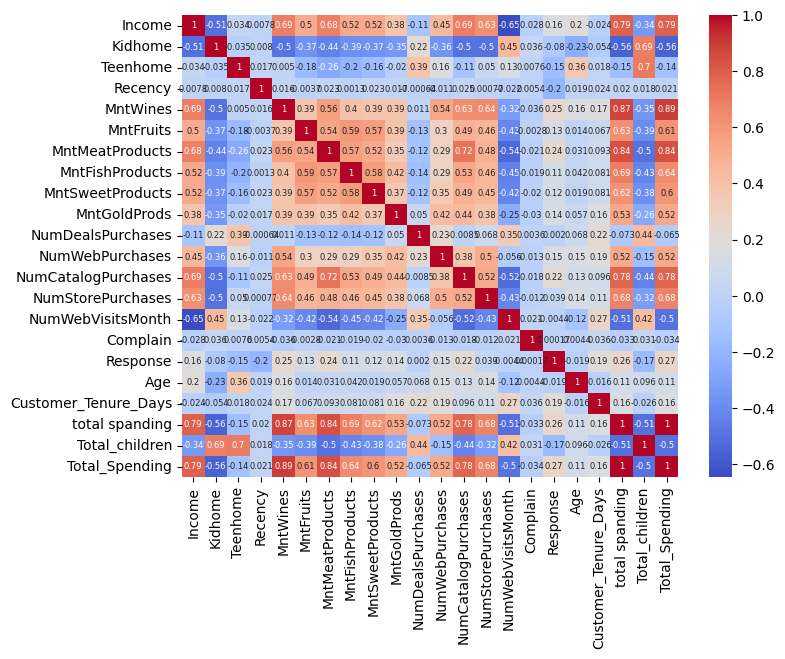

In [91]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)

plt.show()